# Лабораторная работа №6. Многоскоростная обработка сигналов.

Лаборатория цифровой обработки сигналов, МФТИ.

В названии файла заменить `familyname` на свою фамилию. Для выполнения задания требуются два сигнала с цифрового осциллографа (см. задачи 1.2 и 2.1).

Максимальная оценка по данной лабораторной работе ограничивается после дня зачета.  Вклад задач в итоговую оценку при сдаче на занятиях:
* 1.1 - 1 балл,
* 1.2 - 2 балла,
* 1.3 - 1 балл,
* 2.1 - 2 балла, 
* 2.2 - 2 балла,
* 3.1 - 1 балл,
* 3.2 - 1 балл.




In [200]:
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt
def dtft(x, M=2048):
    """
    Функция вычисляет значения ДВПФ в M точках на отрезке 
    по оси нормированных частот [-0.5; 0.5]

    Parameters
    ----------
    x : complex
        входная последовательность отсчетов, первый отсчет при k=0
    M : int
        колличество точек на отрезке [-0.5; 0.5]

    Returns
    -------
    float
        значения оси нормированных частот, 
        соотвествующих вычисленным значениям
        спектральной функции  
    complex
        значения спектральной функции      
    """
    return (np.fft.fftshift(np.fft.fftfreq(M, d=1)), np.fft.fftshift(np.fft.fft(x, M)))
def oscilloscope_file_read(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.closed
    
    figsize=[8, 4]

    # dt
    val, unit = str1[1].replace(',', '.').split(' ')[3:5]
    val=float(val)
    if unit=='uS':
        val*=1e-6
    elif unit=='nS':
        val*=1e-9
    elif unit=='mS':
        val*=1e-3    
    fs = int(1.0 / val)
    
    #Voltage step 
    val, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(val)
    if unit=='mV':
        dv*=1e-3  


    # Zero level
    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev 

def analyse(fs, signal_lev, window='boxcar', stem_signal=False):
    figsize=[8,4]
    plt.rcParams['font.size'] = '12'    
    window = signal.get_window(window, Nx=len(signal_lev), fftbins=True)
    signal_lev = signal_lev*window
    plt.figure(figsize=figsize)
    if stem_signal:
        plt.stem(np.arange(signal_lev.size)/fs*1e3, signal_lev, markerfmt='.')
    else:
        plt.plot(np.arange(signal_lev.size)/fs*1e3, signal_lev, '.-')
    plt.title("Сигнал")
    plt.xlabel("$t$, мc")
    plt.ylabel("$x(k\Delta t)w[k]$, В")
    plt.grid()
    plt.tight_layout()
    Xn = np.fft.fftshift(np.fft.fft(signal_lev, 2**18))
    f = fs*np.linspace(-0.5, 0.5, num=Xn.size, endpoint=False)
#     plt.show()

    plt.figure(figsize=figsize)
    plt.title("ДВПФ (модуль), линейный масштаб")
    plt.plot(f/1e3, abs(Xn))
    plt.grid()
    plt.xlabel("$f$, кГц")
    plt.ylabel("$|X(f)|$")
    plt.tight_layout()
#     plt.show()

    plt.figure(figsize=figsize)
    maxXn=max(abs(Xn))
    plt.title("ДВПФ (модуль), дБ")
    plt.plot(f/1e3, 20*np.log10(abs(Xn)/maxXn))
    plt.grid()
    plt.xlabel("$f$, кГц")
    plt.ylabel("АЧХ, дБ")
    plt.tight_layout()
#     plt.show()

# Модуль 1. Интерполяция сигналов.

## Задача 1.1. Интерполяция сигналов с помощью ДПФ.

| Варианты: |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |   10 |   11 |   12 |   13 |   14 |   15 |   16 |   17 |   18 |   19 |   20 |
|:------|----:|----:|----:|----:|----:|----:|----:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| $N$   |  16 |  16 |  16 |  16 |  16 |  30 |  30 |  30 |  30 |   30 |   20 |   20 |   20 |   20 |   20 |   32 |   32 |   32 |   32 |   32 |
| $A_1$ |   2 |   3 |   4 |   5 |   6 |   2 |   3 |   4 |   5 |    6 |    2 |    3 |    4 |    5 |    6 |    2 |    3 |    4 |    5 |    6 |
| $n_1$ |   3 |   4 |   5 |   6 |   7 |   3 |   4 |   5 |   6 |    7 |    3 |    4 |    5 |    6 |    7 |    3 |    4 |    5 |    6 |    7 |
| $A_2$ |   3 |   5 |   1 |   2 |   5 |   3 |   5 |   1 |   2 |    5 |    3 |    5 |    1 |    2 |    5 |    3 |    5 |    1 |    2 |    5 |
| $n_2$ |   7 |   5 |   7 |   4 |   2 |   7 |   5 |   7 |   4 |    2 |    7 |    5 |    7 |    4 |    2 |    7 |    5 |    7 |    4 |    2 |

Пусть некоторый периодический сигнал $y(t)$ был дискретизован в соответствии с теоремой Котельникова,  $x[k]$ — один период получившейся последовательности отсчетов:
 $$ x[k] = A_1\cos{\left (2\pi\dfrac{n_1}{N} k \right )} + A_2 \cos{\left (2\pi\dfrac{n_2}{N} k \right )}.$$
Произведите интерполяцию с коэффициентом $L=5$ путем добавления нулей в середину ДПФ сигнала $x[k]$. Объясните, почему восстановление сигнала в данном случае точное.

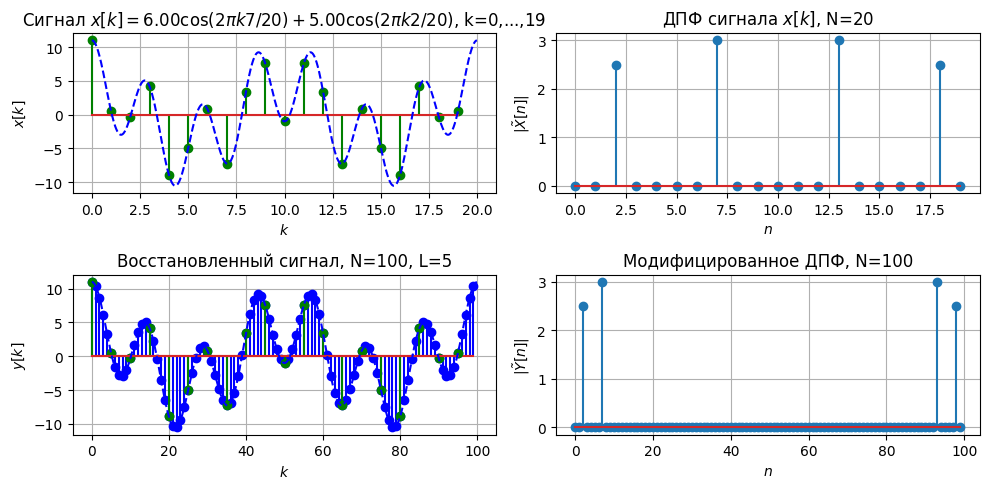

In [201]:
# 15 variant
N=20
A1=6
n1=7
A2=5
n2=2
L=5

k = np.arange(N)
x = A1*np.cos(2*n1*np.pi*k/N) + A2*np.cos(2*n2*np.pi*k/N)

Q=1024
k1=np.arange(Q)

q = A1*np.cos(2*np.pi*n1*k1/Q)+A2*np.cos(2*np.pi*n2*k1/Q)

plt.figure(figsize=[10, 5], dpi=100)
plt.subplot(2,2,1)
plt.stem(np.arange(x.size), x, 'g', markerfmt='go')
plt.plot(N*np.arange(q.size)/Q, q, 'b--')
plt.title(u'Сигнал $x[k]=%.2f\cos(2\\pi k    %i/%i)+%.2f\cos(2\\pi k %i/%i)$, k=0,...,%i' 
          %(A1,n1, N, A2, n2, N, (N-1)))
plt.xlabel(u'$k$')
plt.ylabel(u'$x[k]$')
plt.grid()

Xn=np.fft.fft(x, N)/N
plt.subplot(2,2,2)
plt.stem(np.arange(N), abs(Xn))
plt.title(u'ДПФ сигнала $x[k]$, N=%i' %N);
plt.xlabel(u'$n$');
plt.ylabel(u'$|\\tilde{X}[n]|$');
plt.grid()

if (N%2)==0:
    Yn=np.hstack((Xn[0:(N//2)], Xn[N//2]/2, np.zeros((L-1)*N-1), 
                     Xn[N//2]/2, Xn[(N//2+1):N]))    

plt.subplot(2,2,4)
plt.stem(np.arange(Yn.size), abs(Yn))
plt.title(u'Модифицированное ДПФ, N=%i' %(Yn.size));
plt.xlabel(u'$n$');
plt.ylabel(u'$|\\tilde{Y}[n]|$');
plt.grid()

x2=np.fft.ifft(Yn)*L*N
plt.subplot(2,2,3)
plt.stem(np.arange(x2.size), x2.real,'b', markerfmt='bo')
plt.stem(Yn.size*np.arange(x.size)/N, x, 'g', markerfmt='go')
plt.plot(L*N*np.arange(q.size)/Q, q, 'b--')
plt.title(u'Восстановленный сигнал, N=%i, L=%i' %(Yn.size, L))
plt.xlabel(u'$k$')
plt.ylabel(u'$y[k]$')
plt.grid()
plt.tight_layout()

plt.show()

## Задача 1.2. Система однократной интерполяции.

|             |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |   10 |   11 |   12 |   13 |   14 |   15 |   16 |   17 |   18 |   19 |   20 |
|:------------|----:|----:|----:|----:|----:|----:|----:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| $f_0$, кГц  |  25 |  22 |  23 |  26 |  28 |  25 |  22 |  23 |  26 |   28 |   25 |   22 |   23 |   26 |   28 |   25 |   22 |   23 |   26 |   28 |
| $f_m$, кГц  |  10 |  10 |  10 |  10 |  10 |   9 |   9 |   9 |   9 |    9 |    8 |    8 |    8 |    8 |    8 |    7 |    7 |    7 |    7 |    7 |
| Коэф. АМ, % |  80 |  70 |  80 |  70 |  80 |  70 |  80 |  70 |  80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |   80 |   70 |
| $f_д$, кГц  | 200 | 200 | 200 | 200 | 200 | 200 | 200 | 200 | 200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |  200 |
| $L$         |   3 |   4 |   5 |   3 |   4 |   5 |   4 |   3 |   4 |    5 |    3 |    4 |    5 |    3 |    4 |    5 |    4 |    3 |    4 |    5 |

Промоделируйте работу системы однократной интерполяции с коэффицентом $L$ с помощью функции ``scipy.signal.upfirdn()`` при подаче на ее вход нескольких первых отсчетов (составляющих примерно один период) амплитудно модулированного сигнала с цифрового осциллографа с параметрами из таблицы. 

1. Обоснуйте Ваш выбор КИХ-фильтра для системы интерполяции. Изобразите на графиках его импульсную характеристику $h[k]$, АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы интерполяции во временной области:

* а) входного сигнала $x[k]$,

* б) сигнала $q[k]$, получаемого добавлением $L-1$ отсчета между каждой парой исходных отсчетов,

* в) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$, $h[k]$, $q[k]$ и $y[k]$, иллюстрирующих работу системы интерполяции в частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы интерполяции. 



![pic](data/1.2/1.2.bmp)

In [202]:
fs, x = oscilloscope_file_read("data/1.2/1.2.txt")
N = len(x)
L = 3

fs, N, L

(200000, 1000, 3)

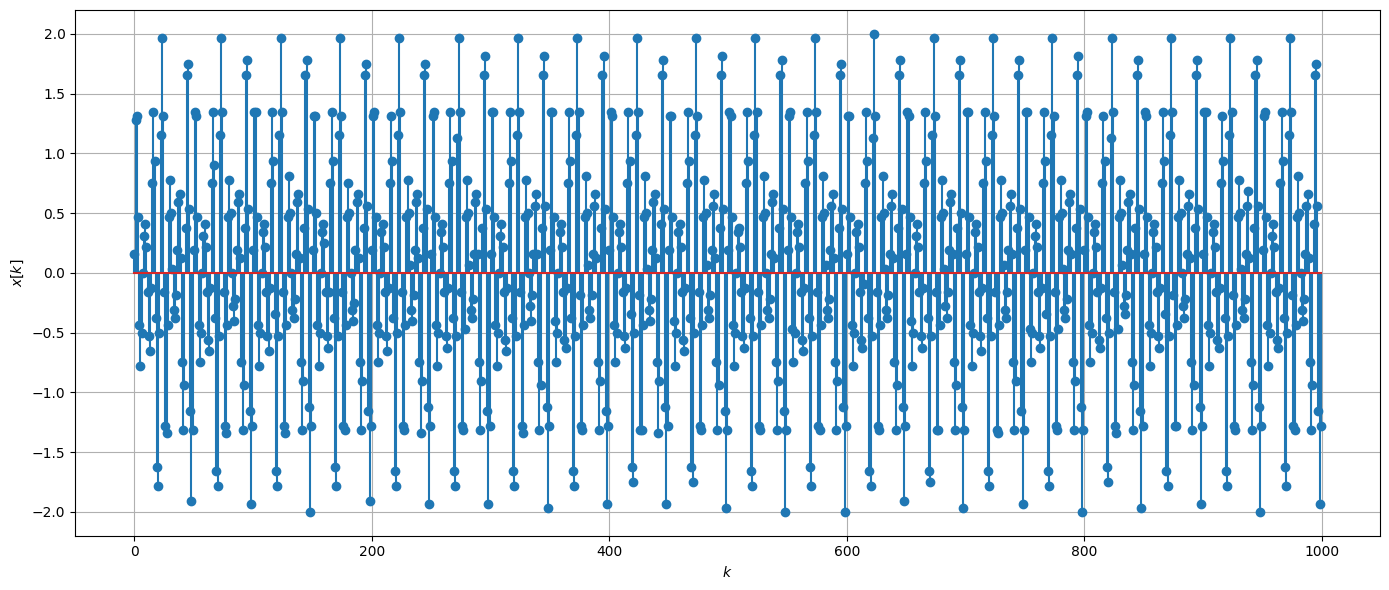

In [203]:
plt.figure(figsize=[14, 6], dpi=100)
plt.stem(np.arange(x.size), x)
plt.xlabel("$k$")
plt.ylabel('$x[k]$')
plt.tight_layout()
plt.grid()

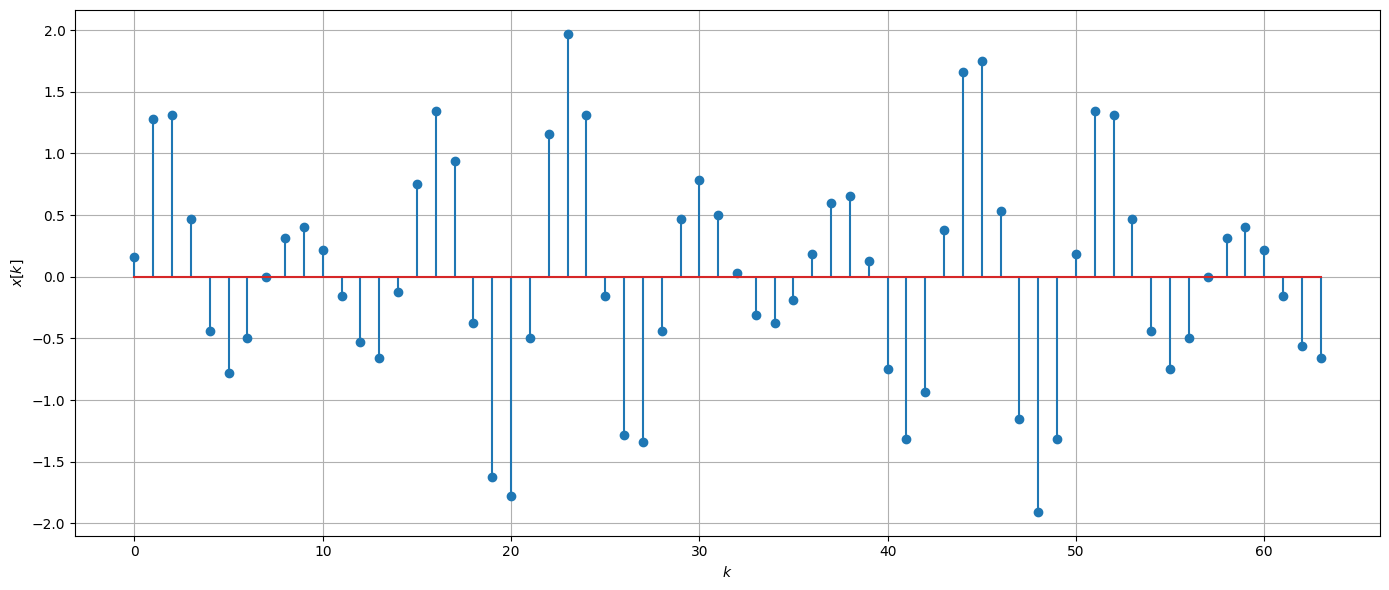

In [204]:
x = x[:64]
N = len(x)
plt.figure(figsize=[14, 6], dpi=100)
plt.stem(np.arange(x.size), x)
plt.xlabel("$k$")
plt.ylabel('$x[k]$')
plt.tight_layout()
plt.grid(True)

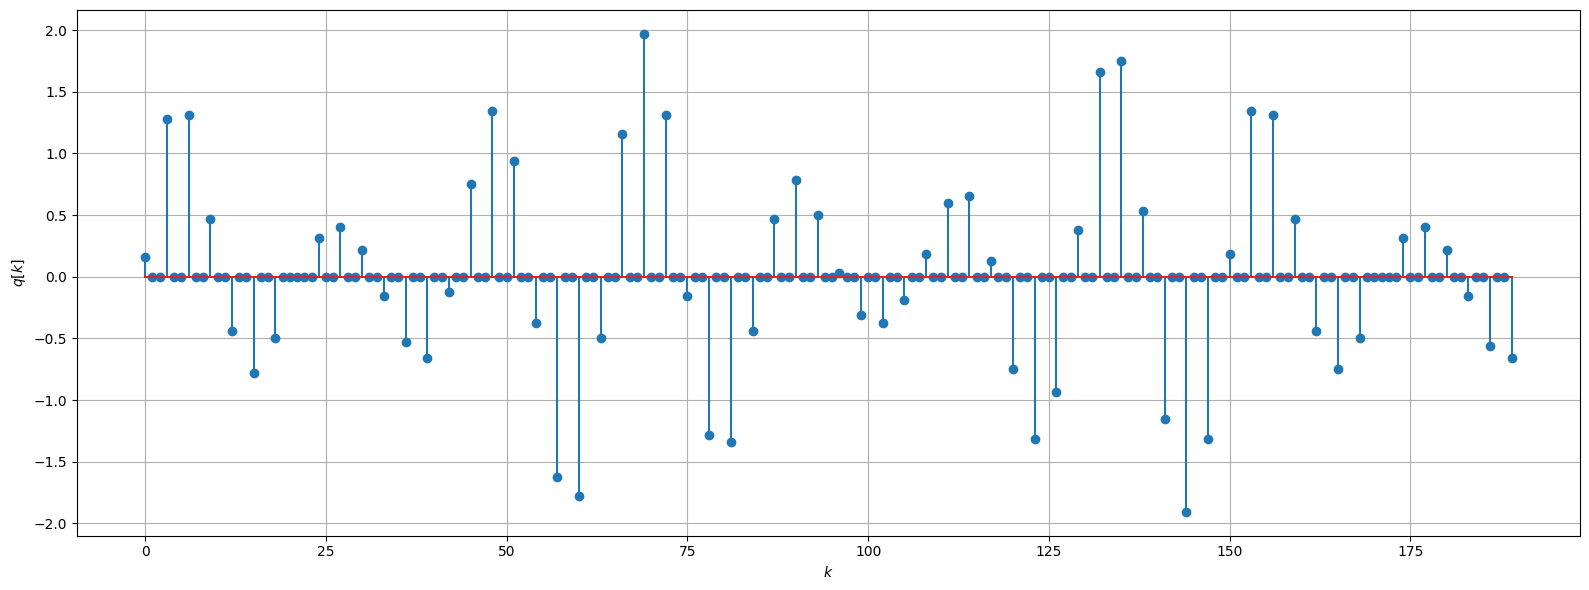

In [205]:
q=signal.upfirdn([1], x, up=L)
plt.figure(figsize=[16, 6], dpi=100)
plt.stem(np.arange(q.size), q)
plt.xlabel("$k$")
plt.ylabel('$q[k]$')
plt.tight_layout()
plt.grid()

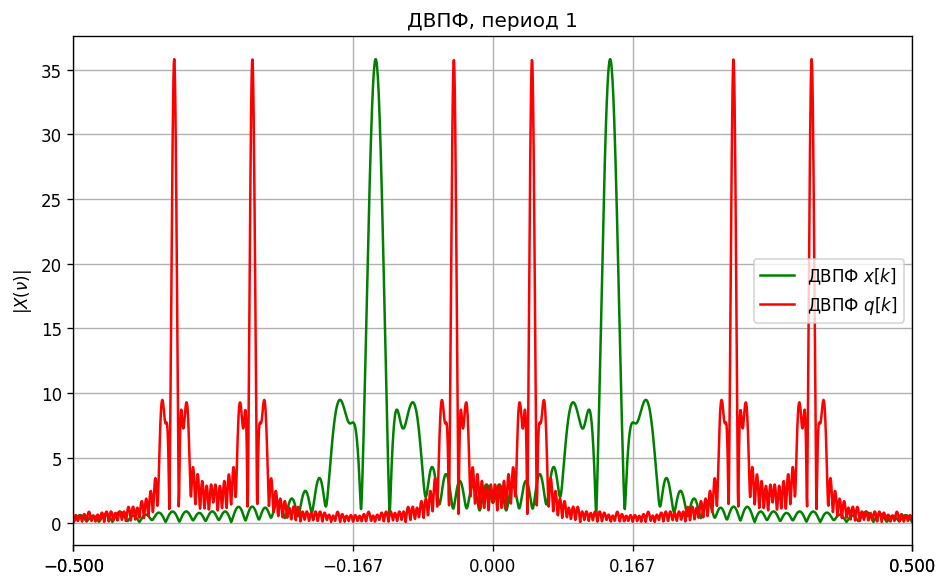

In [206]:
nu1, Xn = dtft(x)
nu2, Q = dtft(q)
plt.figure(figsize=[8, 5], dpi=120)

plt.title(u'ДВПФ, период 1')
plt.plot(nu1, abs(Xn), 'g')
plt.plot(nu2, abs(Q), 'r')
plt.legend([u'ДВПФ $x[k]$', u'ДВПФ $q[k]$'])
plt.ylabel(u'$|X(\\nu)|$')
plt.xlim([-0.5, 0.5])
plt.xticks([-0.5, -3/(2*L), -1/(2*L), 0, 1/(2*L), 3/(2*L), 0.5])
plt.grid(True)

plt.tight_layout()

<Figure size 960x600 with 0 Axes>

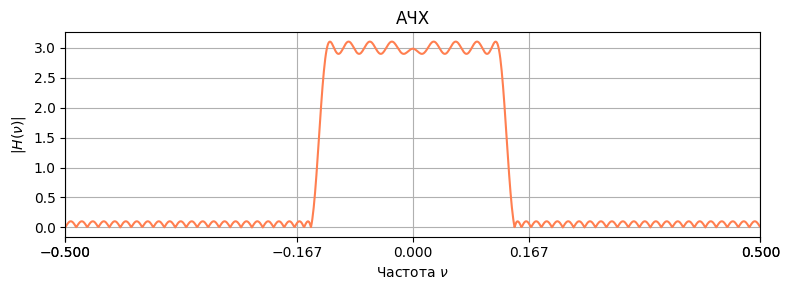

In [207]:
fs=1
f1=1/8
f2=1/8+0.02
bands = np.array([0, f1, f2, fs/2])
desired = np.array([L, 0])
weight = np.array([1, 1])
numtaps=64
h_pm = signal.remez(numtaps=numtaps, bands=bands, desired=desired, weight=weight, fs=fs)

M=1024
plt.figure(figsize=[8, 5], dpi=120)
H1=abs(np.fft.fftshift(np.fft.fft(h_pm, M)))
plt.figure(figsize=[8, 3])
plt.plot(np.arange(M)/M-0.5, H1, color='coral')
plt.grid()
plt.ylabel('$|H(\\nu)|$')
plt.xlabel('Частота $\\nu$')
plt.title('АЧХ')
plt.xlim([-fs/2, fs/2])
plt.xticks([-0.5, -3/(2*L), -1/(2*L), 0, 1/(2*L), 3/(2*L), 0.5])
plt.tight_layout()

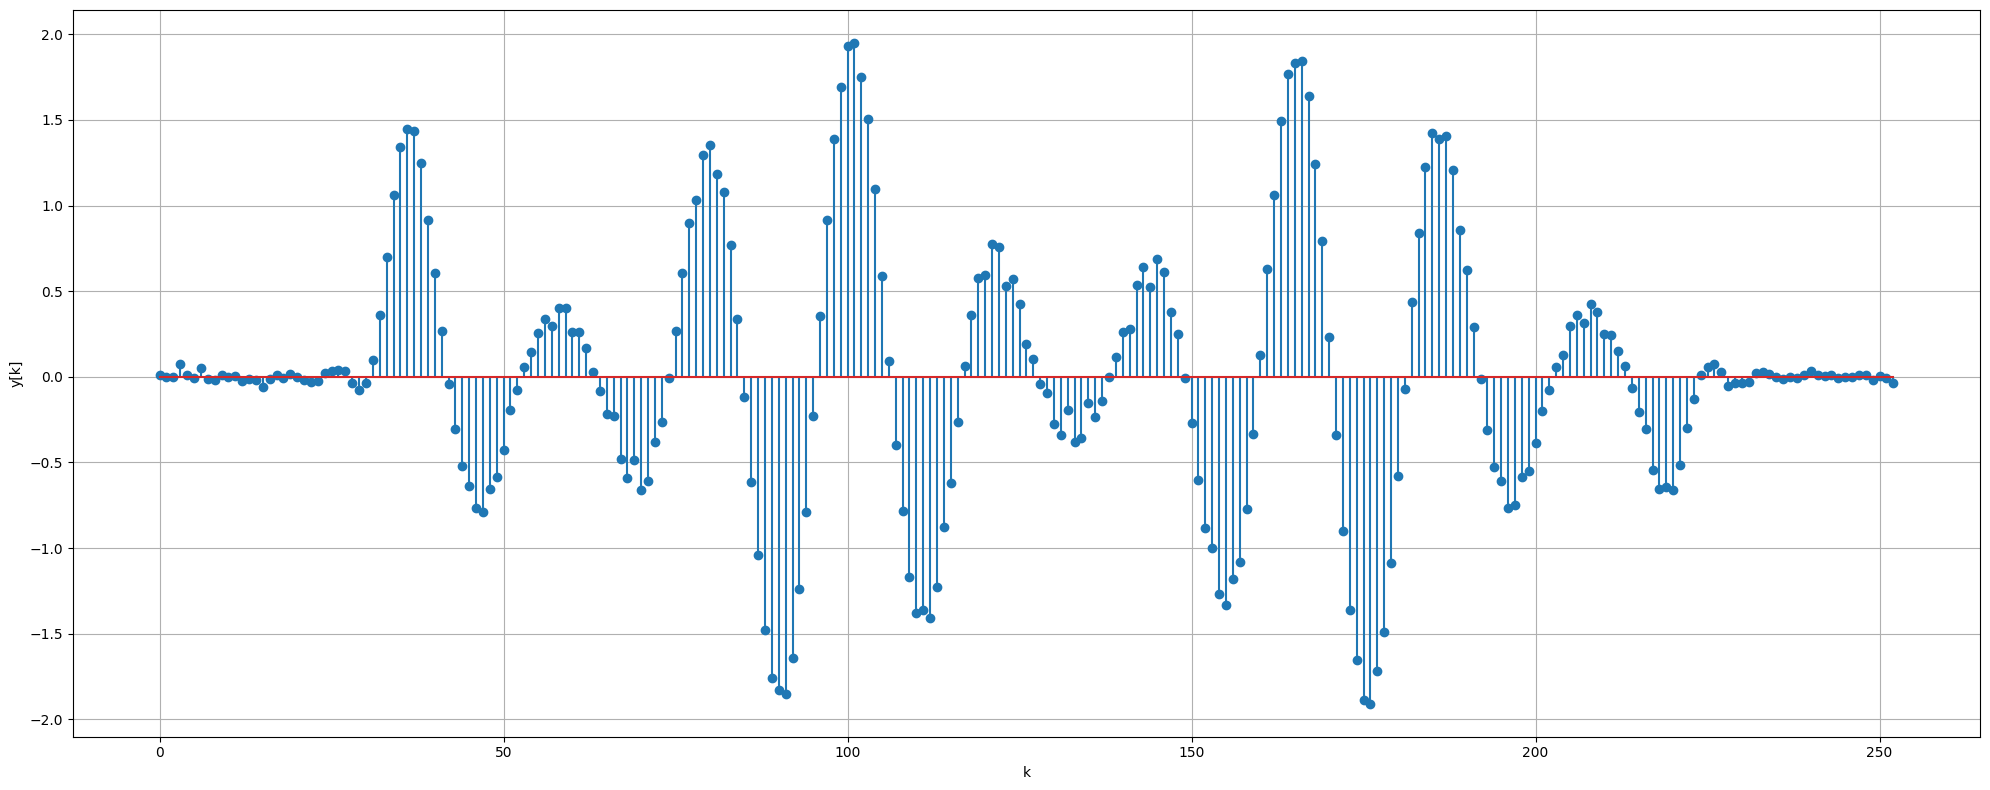

In [208]:
y=signal.upfirdn(h_pm, x, up=L) 
plt.figure(figsize=[20, 8], dpi=100)
plt.stem(np.arange(y.size), y)
plt.xlabel("k")
plt.ylabel('y[k]')
plt.tight_layout()
plt.grid(True)

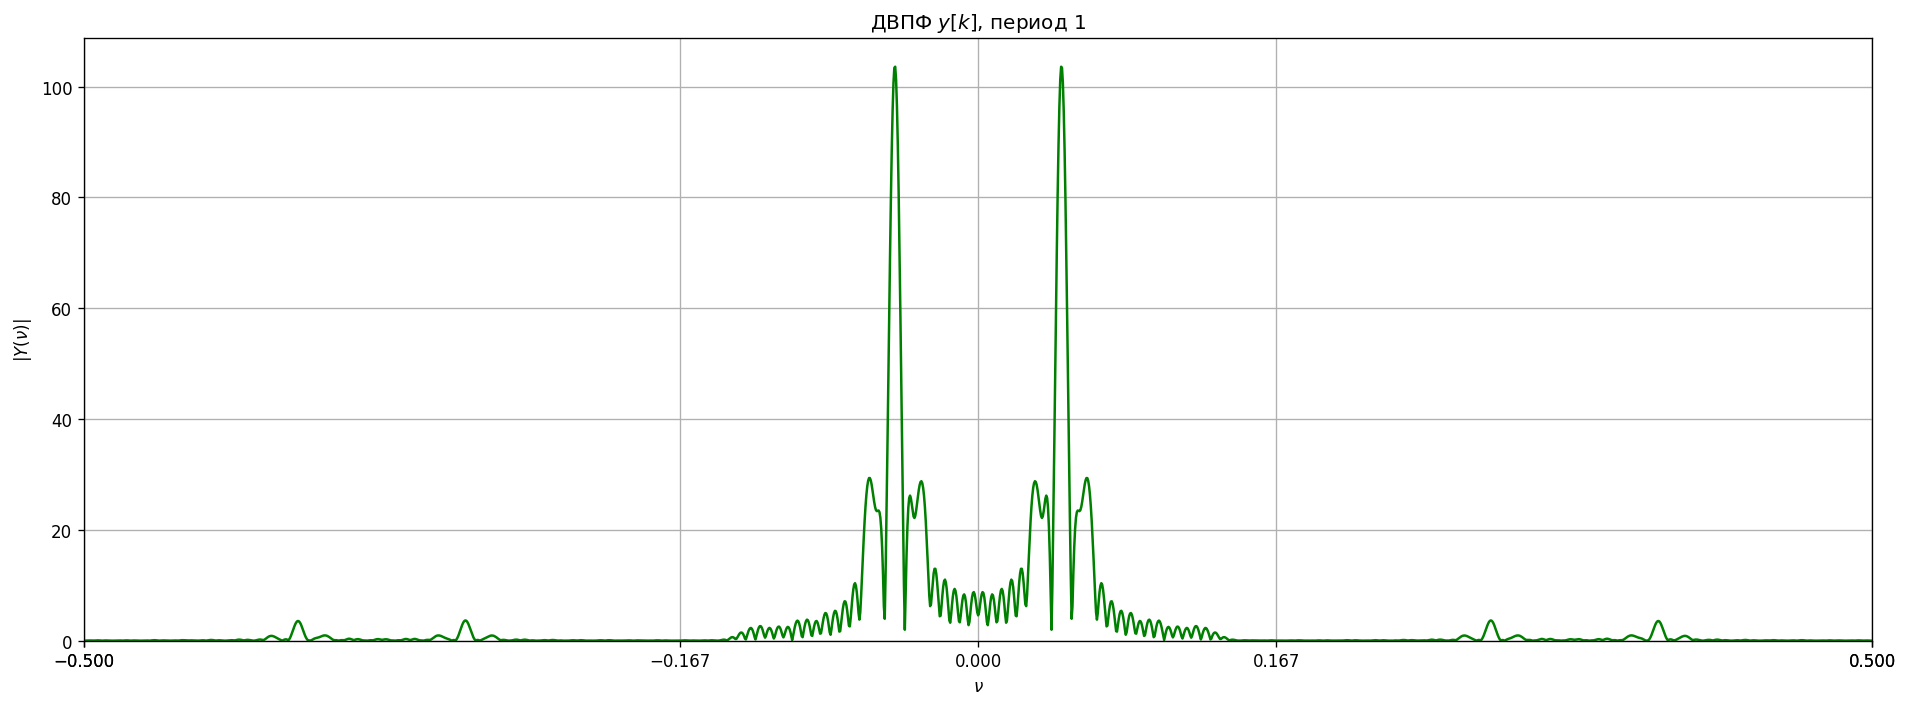

In [209]:
nu, Xn = dtft(y)

plt.figure(figsize=[16, 6], dpi=120)
plt.plot(nu, abs(Xn),'g')
plt.axis(xmin=-0.5, xmax=0.5, ymin=0)
plt.title(u'ДВПФ $y[k]$, период 1')
plt.xlabel(u'$\\nu$')
plt.ylabel(u'$|Y(\\nu)|$')
plt.xlim([-0.5, 0.5])
plt.xticks([-0.5, -3/(2*L), -1/(2*L), 0, 1/(2*L), 3/(2*L), 0.5])
plt.grid()
plt.tight_layout()

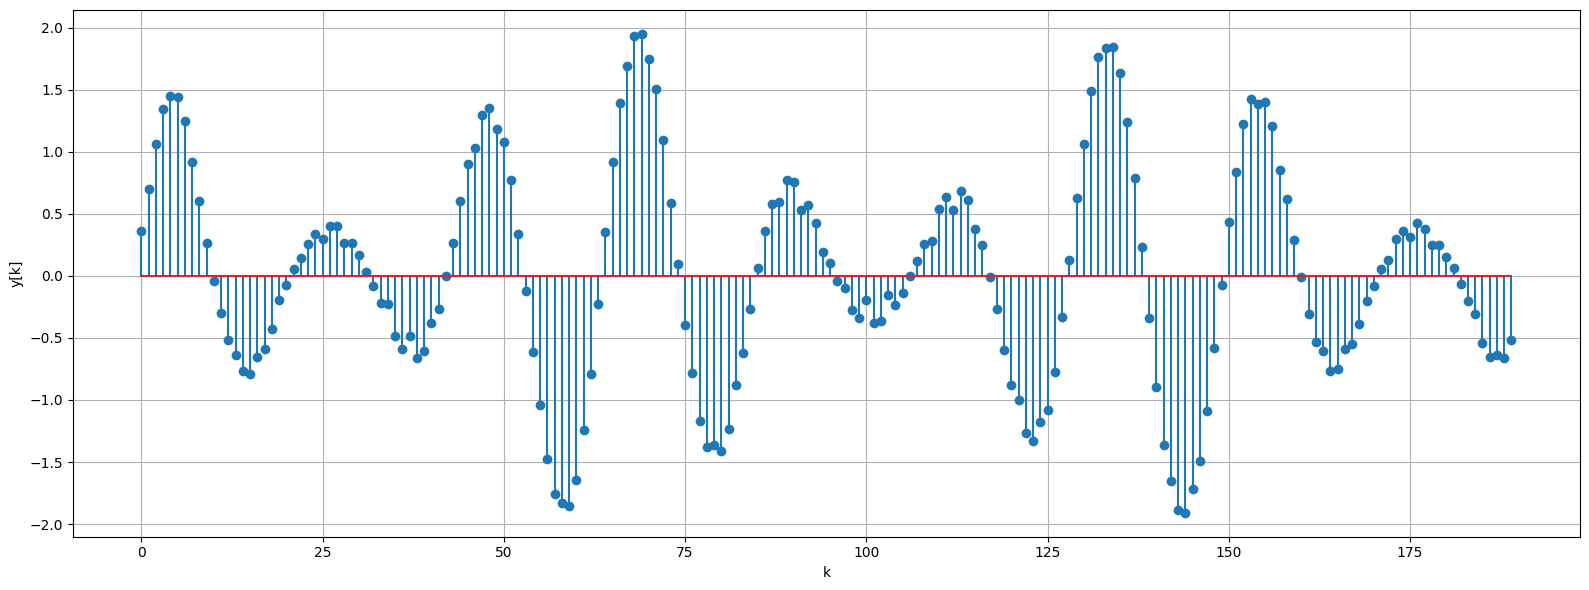

In [210]:
y=signal.upfirdn(h_pm, x, up=L)
y=y[numtaps//2 : -(numtaps//2-1)]
plt.figure(figsize=[16, 6], dpi=100)
plt.stem(np.arange(y.size), y)
plt.xlabel("k")
plt.ylabel('y[k]')
plt.tight_layout()
plt.grid()

Было 64 отсчета на период, стало 190 $$ T = \frac{N}{f_d} = \frac{\~N}{\~f_d} \rightarrow \~f_d = \frac{\~N}{N}f_d = \frac{\~N}{N}f_d = L f_d = 3f_d$$

## Задача 1.3. Интерполяция первого и нулевого порядка.

Повторите вычисления задачи 1.2 для КИХ-фильтров с импульсными характеристиками ${{h}_{0}}[k]$ и ${{h}_{1}}[k]$ и $L=2$. Сравните результаты.

${{h}_{0}}[k]=\left\{ \begin{matrix}
   1,\ \ \text{ при }k=0,\ \ 1,  \\
   0,\ \ \text{ при других }k.  \\
\end{matrix} \right.$

${{h}_{1}}[k]=\left\{ \begin{matrix}
   0,5,\ \ \text{ при }k=0,\ \ 2,  \\
   1,\ \ \text{ при }k=1,  \\
   0,\ \ \text{ при других  }k.  \\
\end{matrix} \right.$



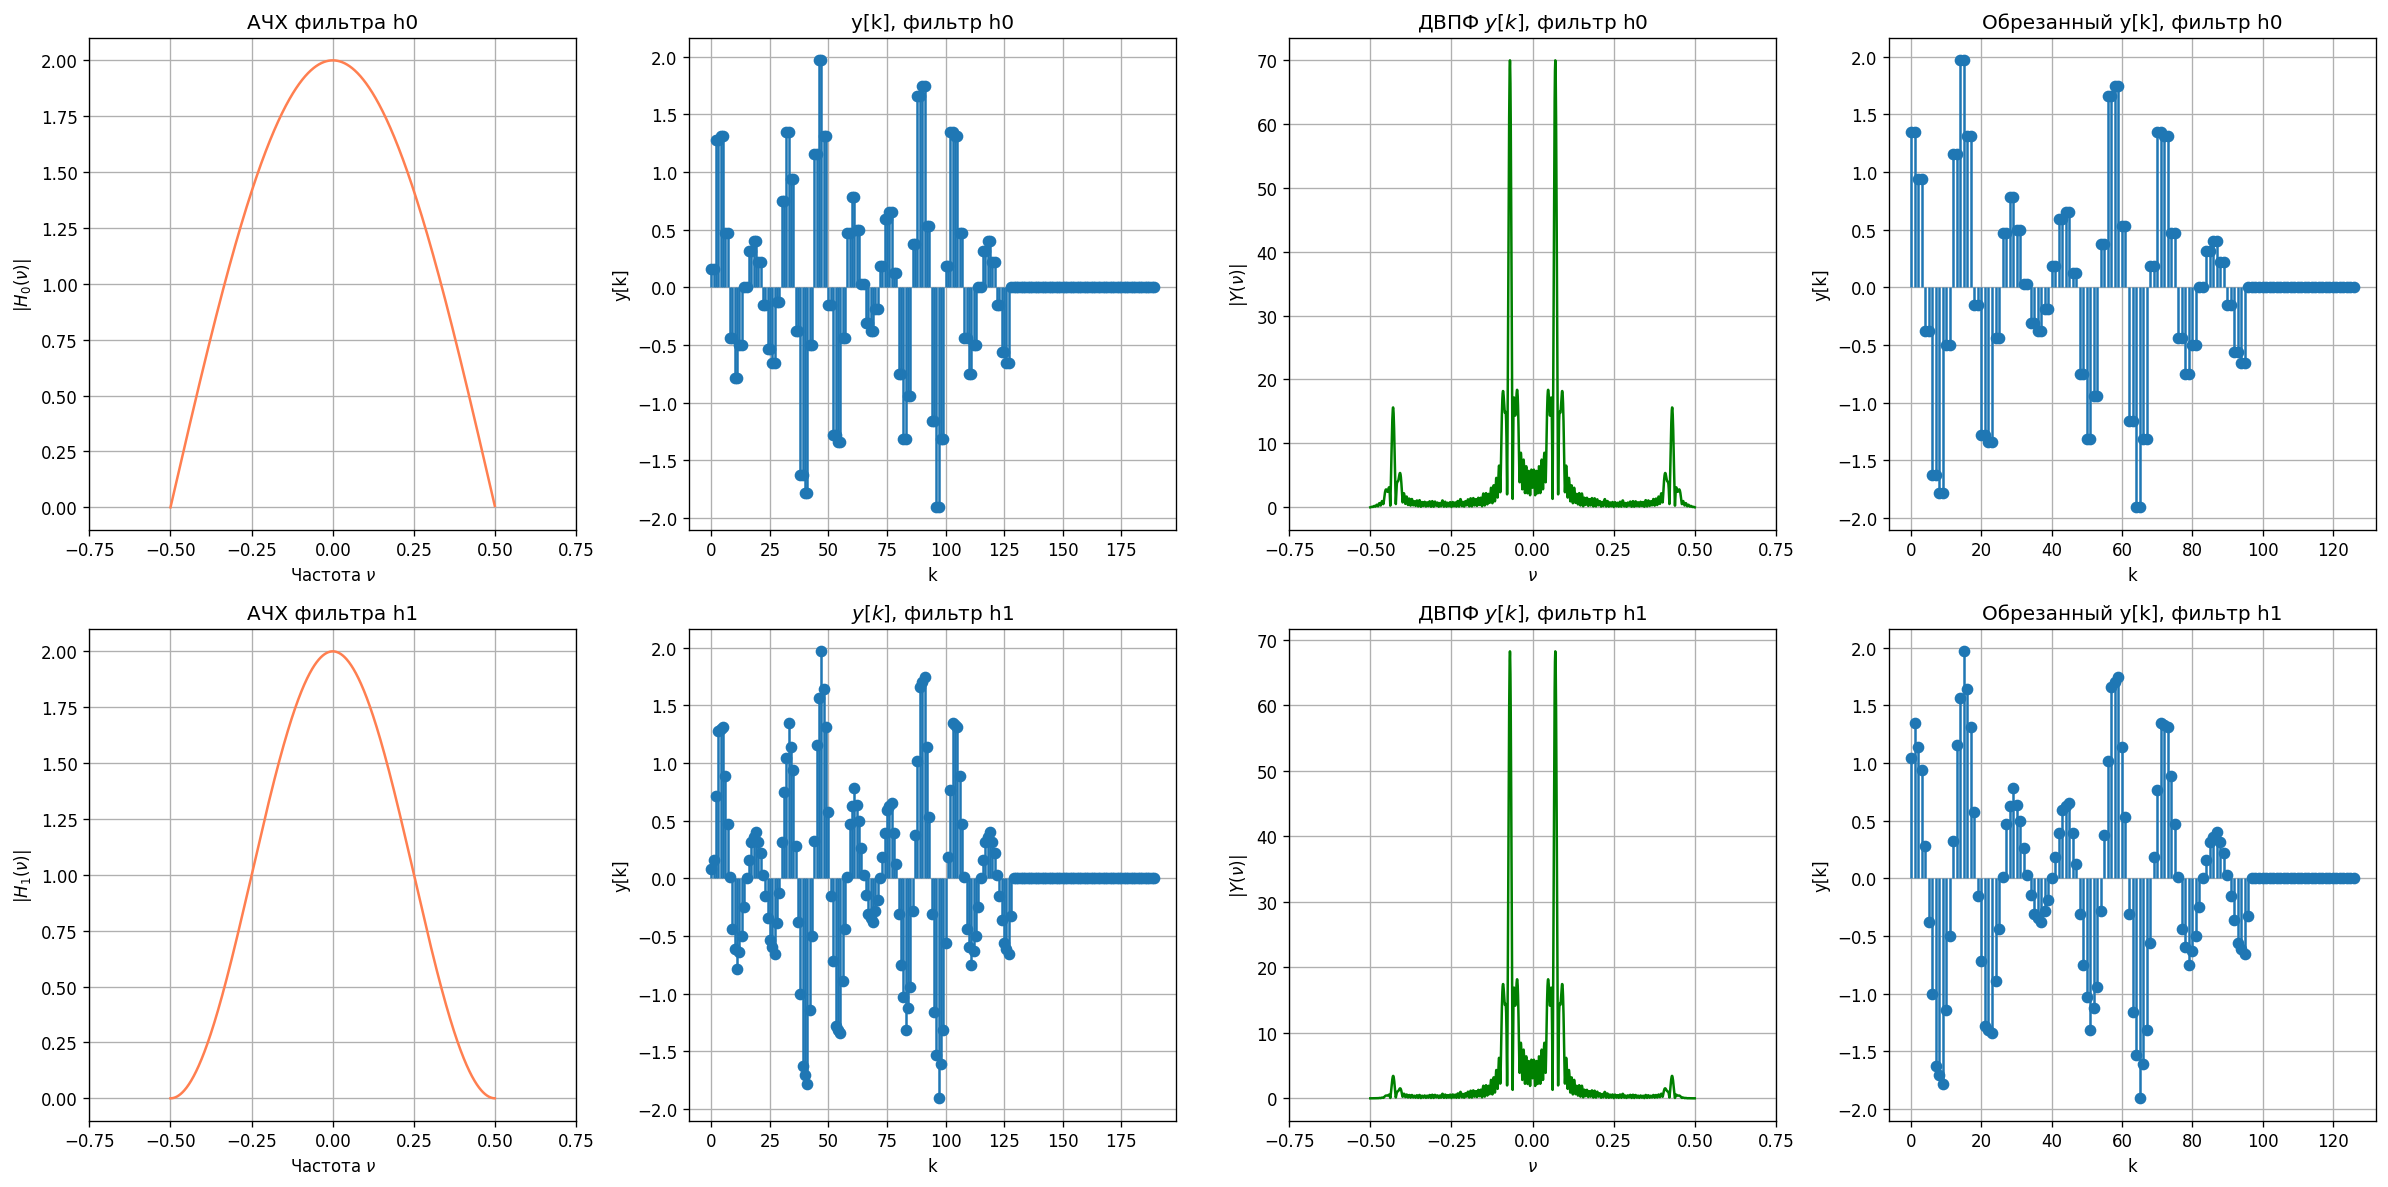

In [211]:
h0 = np.zeros(N)
h0[0:2] = 1

h1 = np.zeros(N)
h1[0] = 0.5
h1[2] = 0.5
h1[1] = 1

L = 2

M = 1024

fig, axes = plt.subplots(2, 4, figsize=(20, 10), dpi=120)
axes = axes.flatten()

# --- Plot 1: Frequency response of h0 ---
H0 = abs(np.fft.fftshift(np.fft.fft(h0, M)))
axes[0].plot(np.arange(M) / M - 0.5, H0, color="coral")
axes[0].set_title("АЧХ фильтра h0")
axes[0].set_xlabel("Частота $\\nu$")
axes[0].set_ylabel("$|H_0(\\nu)|$")
axes[0].set_xlim([-0.5, 0.5])
axes[0].set_xticks([-0.5, -3 / (2 * L), -1 / (2 * L), 0, 1 / (2 * L), 3 / (2 * L), 0.5])
axes[0].grid()

# --- Plot 2: y[k] using h0 ---
y = signal.upfirdn(h0, x, up=L)
axes[1].stem(np.arange(y.size), y, basefmt=" ")
axes[1].set_title("y[k], фильтр h0")
axes[1].set_xlabel("k")
axes[1].set_ylabel("y[k]")
axes[1].grid()

# --- Plot 3: DTFT of y[k] (h0) ---
nu, Xn = dtft(y)
axes[2].plot(nu, abs(Xn), "g")
axes[2].set_title("ДВПФ $y[k]$, фильтр h0")
axes[2].set_xlabel("$\\nu$")
axes[2].set_ylabel("$|Y(\\nu)|$")
axes[2].set_xlim([-0.5, 0.5])
axes[2].set_xticks([-0.5, -3 / (2 * L), -1 / (2 * L), 0, 1 / (2 * L), 3 / (2 * L), 0.5])
axes[2].grid()

# --- Plot 4: Trimmed y[k] (h0) ---
y = y[numtaps // 2 : -(numtaps // 2 - 1)]
axes[3].stem(np.arange(y.size), y, basefmt=" ")
axes[3].set_xlabel("k")
axes[3].set_ylabel("y[k]")
axes[3].set_title("Обрезанный y[k], фильтр h0")
axes[3].grid()

# --- Plot 5: Frequency response of h1 ---
H1 = abs(np.fft.fftshift(np.fft.fft(h1, M)))
axes[4].plot(np.arange(M) / M - 0.5, H1, color="coral")
axes[4].set_title("АЧХ фильтра h1")
axes[4].set_xlabel("Частота $\\nu$")
axes[4].set_ylabel("$|H_1(\\nu)|$")
axes[4].set_xlim([-0.5, 0.5])
axes[4].set_xticks([-0.5, -3 / (2 * L), -1 / (2 * L), 0, 1 / (2 * L), 3 / (2 * L), 0.5])
axes[4].grid()

# --- Plot 6: y[k] using h1 ---
y = signal.upfirdn(h1, x, up=L)
axes[5].stem(np.arange(y.size), y, basefmt=" ")
axes[5].set_title("$y[k]$, фильтр h1")
axes[5].set_xlabel("k")
axes[5].set_ylabel("y[k]")
axes[5].grid()

# --- Plot 7: DTFT of y[k] (h1) ---
nu, Xn = dtft(y)
axes[6].plot(nu, abs(Xn), "g")
axes[6].set_title("ДВПФ $y[k]$, фильтр h1")
axes[6].set_xlabel("$\\nu$")
axes[6].set_ylabel("$|Y(\\nu)|$")
axes[6].set_xlim([-0.5, 0.5])
axes[6].set_xticks([-0.5, -3 / (2 * L), -1 / (2 * L), 0, 1 / (2 * L), 3 / (2 * L), 0.5])
axes[6].grid()

# --- Plot 8: Trimmed y[k] (h1) ---
y = y[numtaps // 2 : -(numtaps // 2 - 1)]
axes[7].stem(np.arange(y.size), y, basefmt=" ")
axes[7].set_xlabel("k")
axes[7].set_ylabel("y[k]")
axes[7].set_title("Обрезанный y[k], фильтр h1")
axes[7].grid()

plt.tight_layout()
plt.show()
plt.close()

#  Модуль 2. Прореживание сигналов и передискретизация с рациональным шагом.

## Задача 2.1. Система однократной децимации.

| Варианты: |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |   10 |   11 |   12 |   13 |   14 |   15 |   16 |   17 |   18 |   19 |   20 |
|:-----------|----:|----:|----:|----:|----:|----:|----:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| $f_0$, кГц |  80 |  90 | 100 | 110 | 120 | 130 | 140 | 150 | 160 |  170 |  180 |  190 |  200 |  210 |  220 |  230 |  240 |  250 |  260 |  270 |
| $f_д$, МГц |  10 |  20 |  10 |  20 |  10 |  20 |  10 |  20 |  10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |   10 |   20 |
| $M$        |   5 |  10 |   5 |  10 |   5 |  10 |   5 |  10 |   5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |    5 |   10 |

Промоделируйте работу системы однократной децимации с коэффицентом $M$ при подаче на ее вход нескольких первых отсчетов синусоидального сигнала с цифрового осциллографа с параметрами из таблицы. 

1. Обоснуйте Ваш выбор фильтра для системы децимации. Изобразите на графиках его импульсную характеристику $h[k]$, АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы интерполяции во временной области:

* а) входного сигнала $x[k]$,

* б) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$ и $y[k]$, иллюстрирующих работу системы интерполяции во частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы. 

![pic](data/2.1/2.1.bmp)

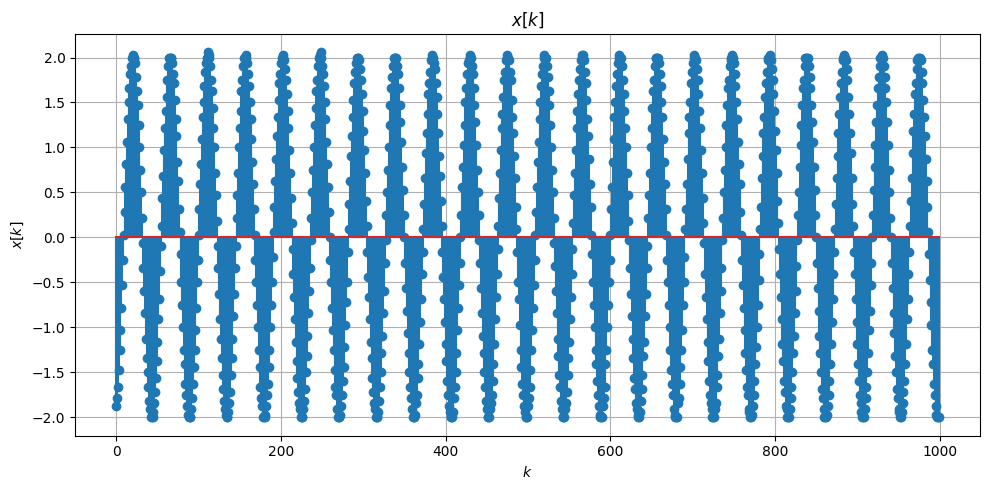

In [212]:
fs, x = oscilloscope_file_read("data/2.1/2.1.txt")
N = len(x)
M = 5
plt.figure(figsize=[10, 5], dpi=100)
plt.stem(np.arange(x.size), x)
plt.title("$x[k]$")
plt.xlabel("$k$")
plt.ylabel("$x[k]$")
plt.tight_layout()
plt.grid()

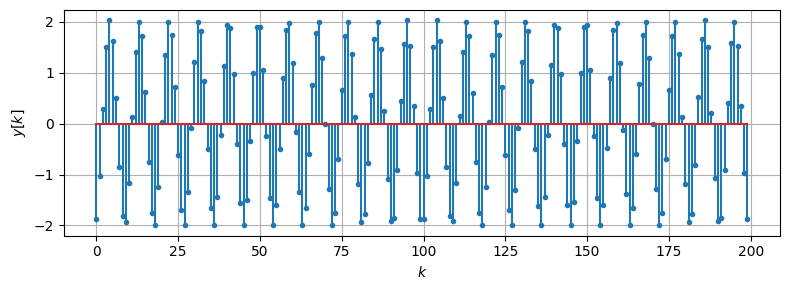

In [213]:
y = signal.upfirdn([1], x, up=1, down=M)
plt.figure(figsize=[8, 3], dpi=100)
plt.stem(np.arange(y.size), y, markerfmt=".")
plt.xlabel("$k$")
plt.ylabel("$y[k]$")
plt.tight_layout()
plt.grid()

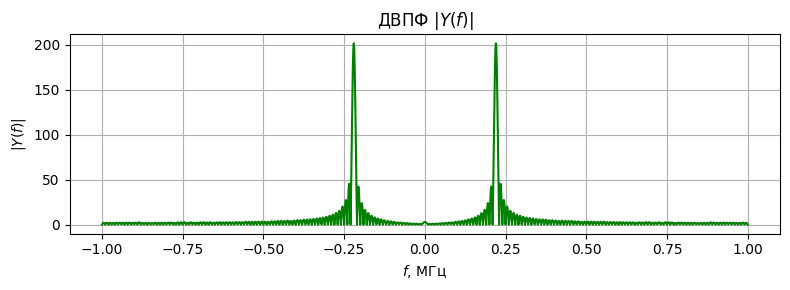

In [214]:
nu, Xn = dtft(y, M=2**18)

plt.figure(figsize=[8, 3], dpi=100)
plt.plot((fs * nu) / M / 1e6, abs(Xn), "g")
plt.title("ДВПФ $|Y(f)|$")
plt.xlabel("$f$, МГц")
plt.ylabel("$|Y(f)|$")
plt.grid()
plt.tight_layout()
plt.show()

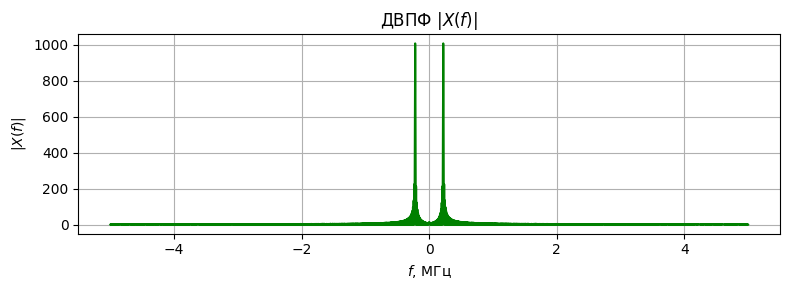

In [215]:
nu, Xn = dtft(x, M=2**18)

plt.figure(figsize=[8, 3], dpi=100)
plt.plot(fs * nu / 1e6, abs(Xn), "g")
plt.title("ДВПФ $|X(f)|$")
plt.xlabel("$f$, МГц")
plt.ylabel("$|X(f)|$")
plt.grid()
plt.tight_layout()
plt.show()

## Задача 2.2. Система однократной передискретизации с рациональным шагом.

Промоделируйте работу системы однократной передискретизации с коэффицентом $L/M=5/2$ при подаче на ее вход сигнала из задачи 2.1.

1. Обоснуйте Ваш выбор фильтра для однократной передискретизации. Изобразите на графиках его АЧХ и ФЧХ.

2. Постройте графики, иллюстрирующие работу системы передискретизации во временной области:

* а) входного сигнала $x[k]$,

* б) выходного сигнала $y[k]$.

3. Постройте графики модуля ДВПФ последовательностей $x[k]$ и $y[k]$, иллюстрирующих работу системы передискретизации во частотной области.

4. Укажите шаг и частоту дискретизации выходного сигнала системы. 

In [216]:
L, M = 5, 2
fs, x = oscilloscope_file_read("data/2.1/2.1.txt")
N = len(x)

Фильтр берем с прямоугольным АЧХ, у которого $$|\nu| \leq min \left\{\frac{1}{2M}; \frac{1}{2L} \right\} = \frac{1}{2L}$$ 

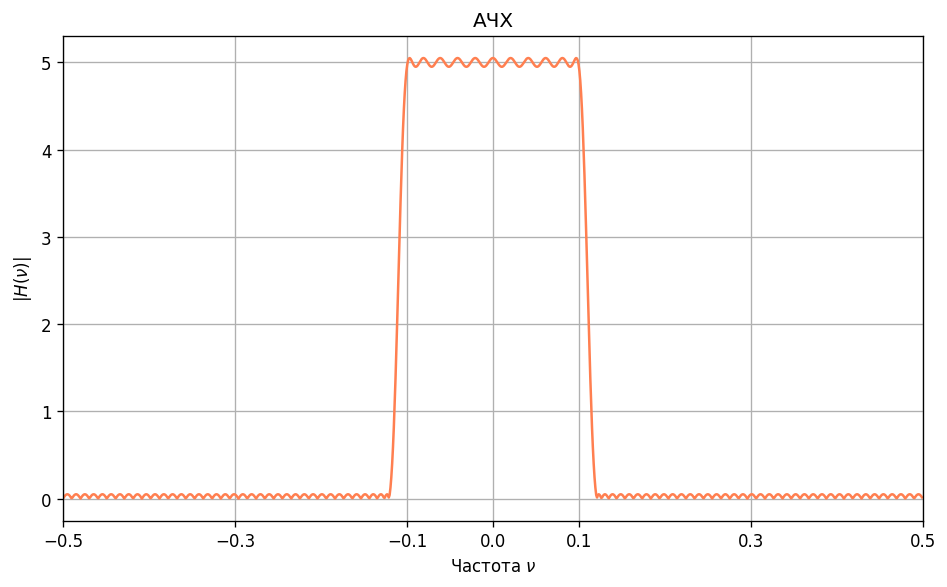

In [217]:
fs=1
f1=1/(2*L)
f2=1/(2*L)+0.02
bands = np.array([0, f1, f2, fs/2])
desired = np.array([L, 0])
weight = np.array([1, 1])
numtaps=100
h_pm = signal.remez(numtaps=numtaps, bands=bands, desired=desired, weight=weight, fs=fs)

Q=1024
plt.figure(figsize=[8, 5], dpi=120)
H1=abs(np.fft.fftshift(np.fft.fft(h_pm, Q)))
plt.plot(np.arange(Q)/Q-0.5, H1, color='coral')
plt.grid()
plt.ylabel('$|H(\\nu)|$')
plt.xlabel('Частота $\\nu$')
plt.title('АЧХ')
plt.xlim([-fs/2, fs/2])
plt.xticks([-0.5, -3/(2*L), -1/(2*L), 0, 1/(2*L), 3/(2*L), 0.5])
plt.tight_layout()
plt.show()
plt.close()

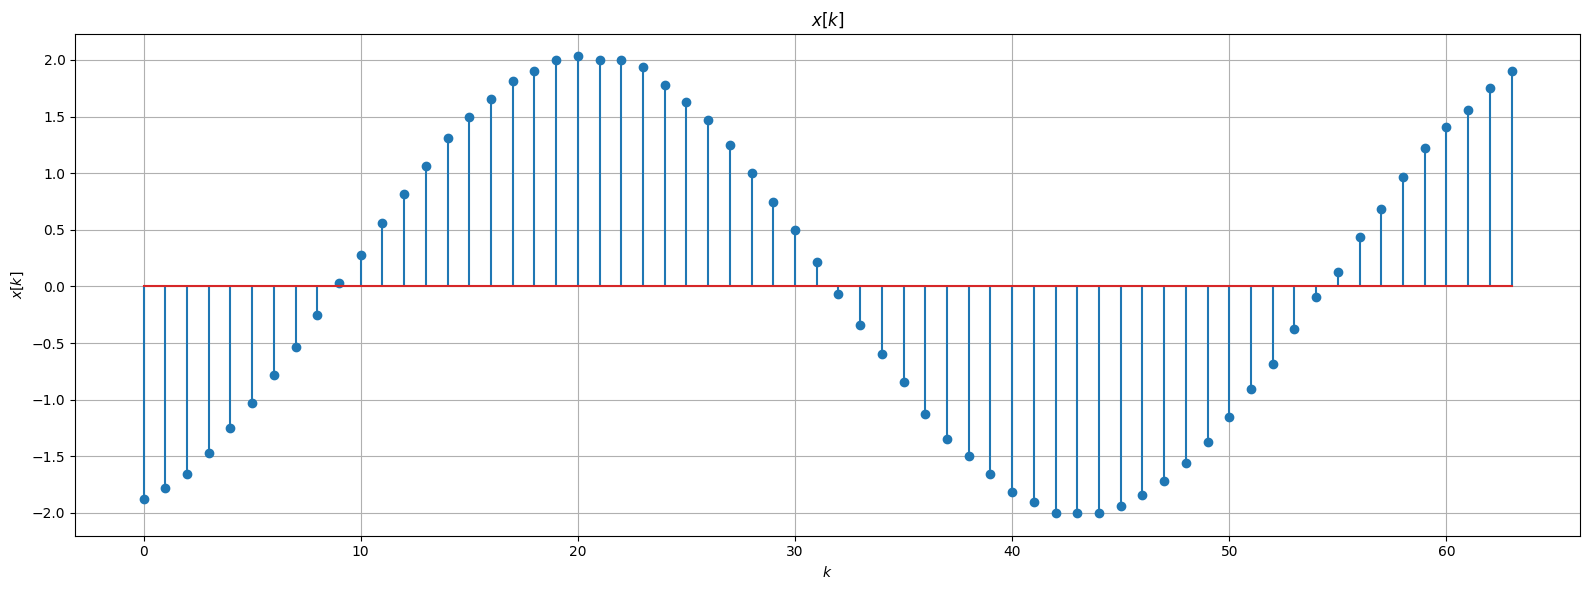

In [218]:
x = x[:64]
plt.figure(figsize=[16, 6], dpi=100)
plt.stem(np.arange(x.size), x)
plt.title("$x[k]$")
plt.xlabel("$k$")
plt.ylabel("$x[k]$")
plt.tight_layout()
plt.grid()

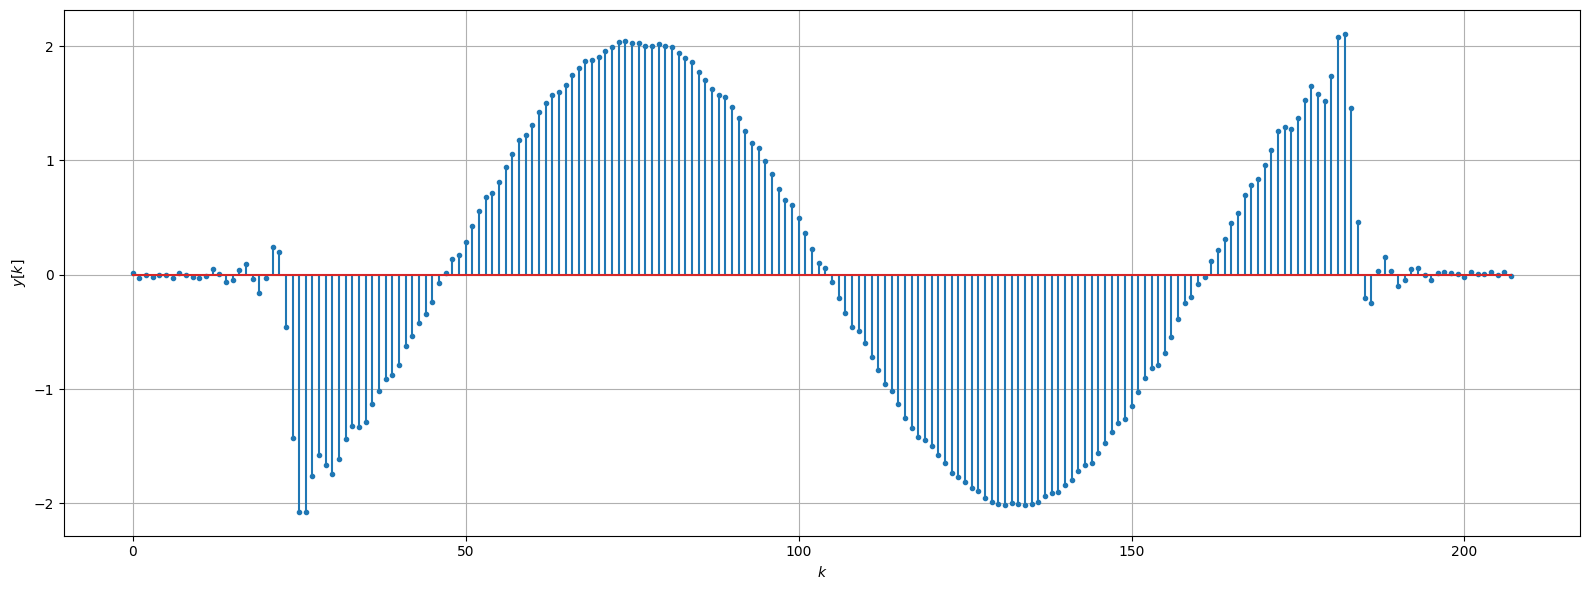

In [219]:
y=signal.upfirdn(h_pm, x, up=L, down=M)
plt.figure(figsize=[16, 6], dpi=100)
plt.stem(np.arange(y.size), y, markerfmt='.')
plt.xlabel("$k$")
plt.ylabel('$y[k]$')
plt.tight_layout()
plt.grid()

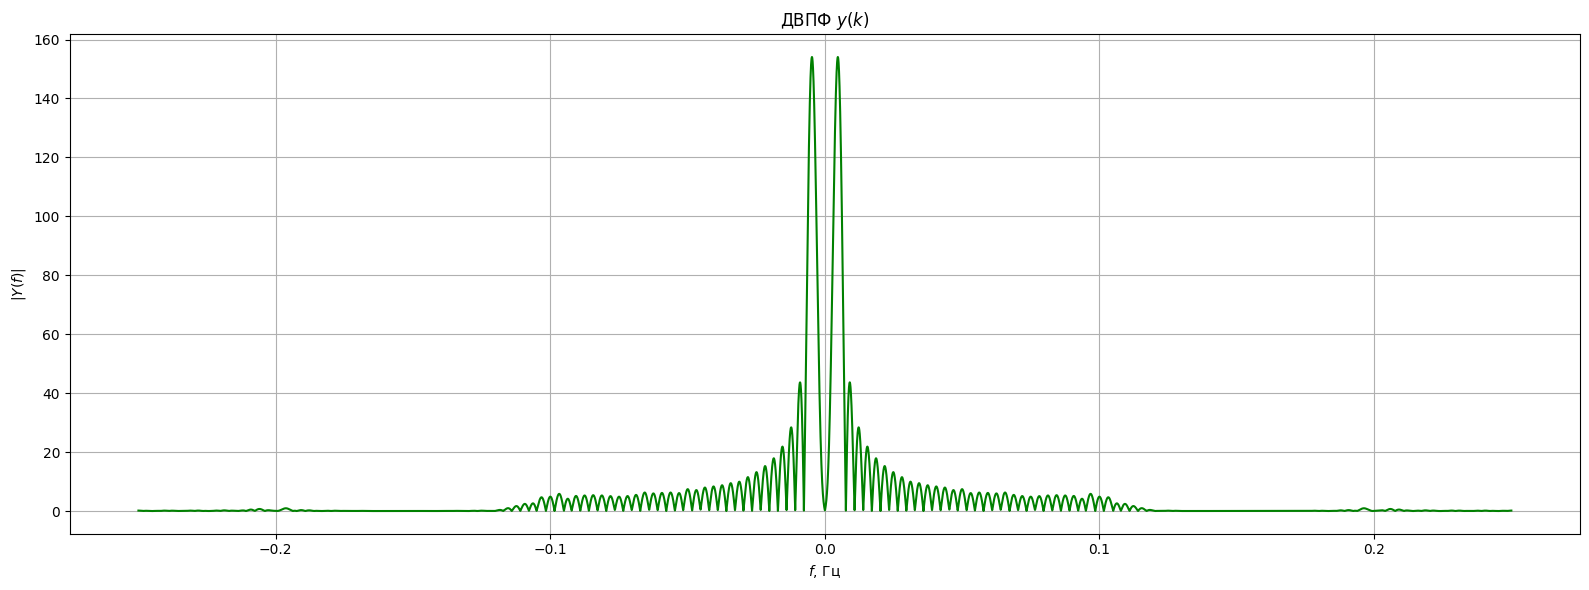

In [220]:
nu, Xn = dtft(y, M=2**18)

plt.figure(figsize=[16, 6], dpi=100)
plt.plot((fs * nu) / M, abs(Xn), "g")
plt.title("ДВПФ $y(k)$")
plt.xlabel("$f$, Гц")
plt.ylabel("$|Y(f)|$")
plt.grid()
plt.tight_layout()
plt.show()

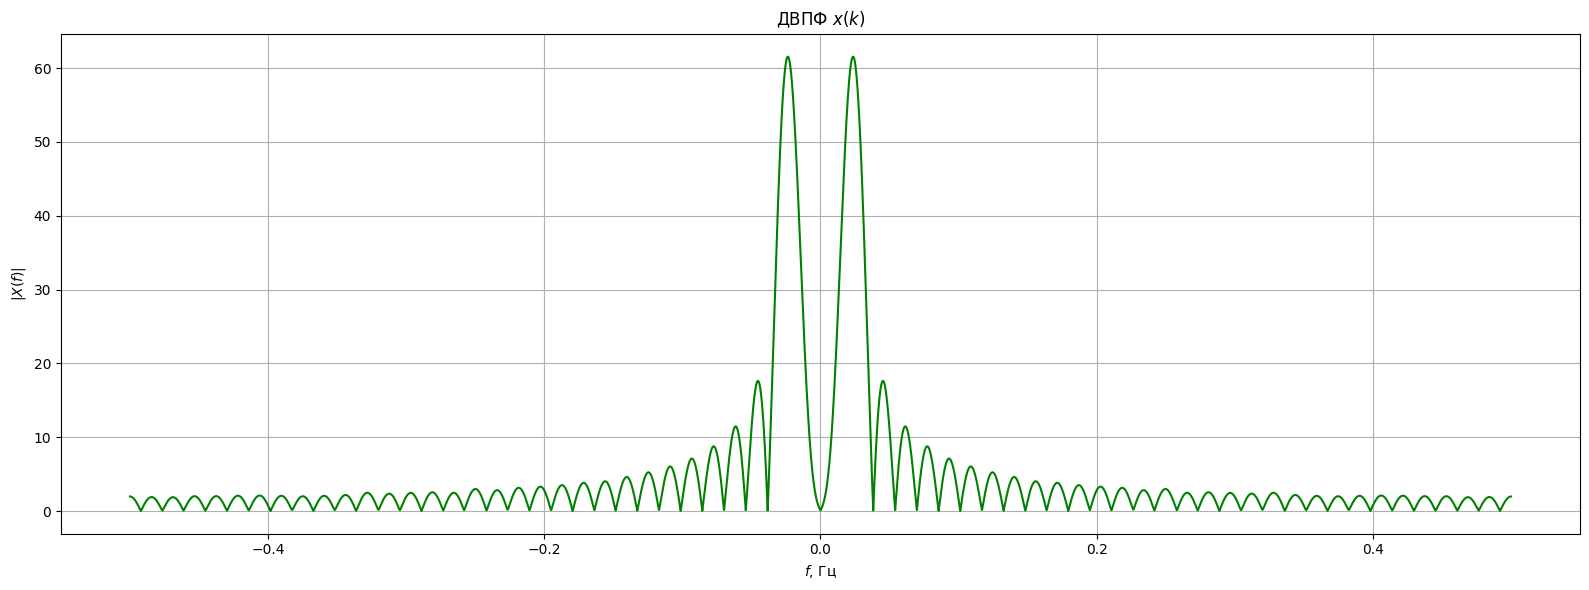

In [221]:
nu, Xn = dtft(x, M=2**18)

plt.figure(figsize=[16, 6], dpi=100)
plt.plot(fs * nu, abs(Xn), "g")
plt.title("ДВПФ $x(k)$")
plt.xlabel("$f$, Гц")
plt.ylabel("$|X(f)|$")
plt.grid()
plt.tight_layout()
plt.show()

#  Модуль 3. Особенности реализации многоскоростных систем.

## Задача 3.1. Полифазные структуры многоскоростных систем.

Промоделируйте работу системы однократной интерполяции с коэффицентом $L=4$ при подаче на ее вход сигнала из задачи 2.1 с помощью функции ``scipy.signal.resample_poly()``.


1. Постройте графики входного ($x[k]$) и выходного ($y[k]$) сигналов, и модулей их ДВПФ.

2. Изобразите схему данной полифазной структуры однократной интерполяции. 

3. Укажите шаг и частоту дискретизации выходного сигнала системы. 


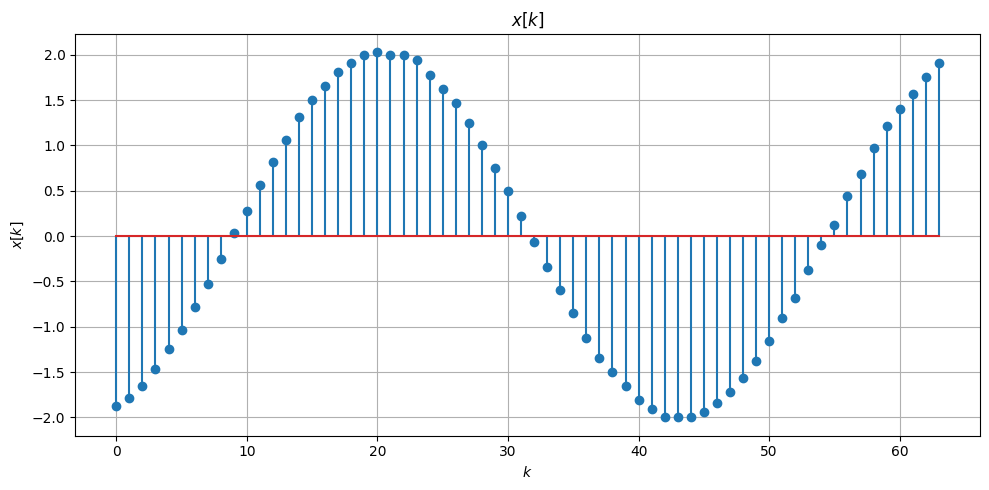

In [222]:
fs, x = oscilloscope_file_read("data/2.1/2.1.txt")
N = len(x)
L = 4
x = x[:64]

y = signal.resample_poly(x, up=L, down=1)
plt.figure(figsize=[10, 5], dpi=100)
plt.stem(x)
plt.title("$x[k]$")
plt.xlabel("$k$")
plt.ylabel("$x[k]$")
plt.tight_layout()
plt.grid()


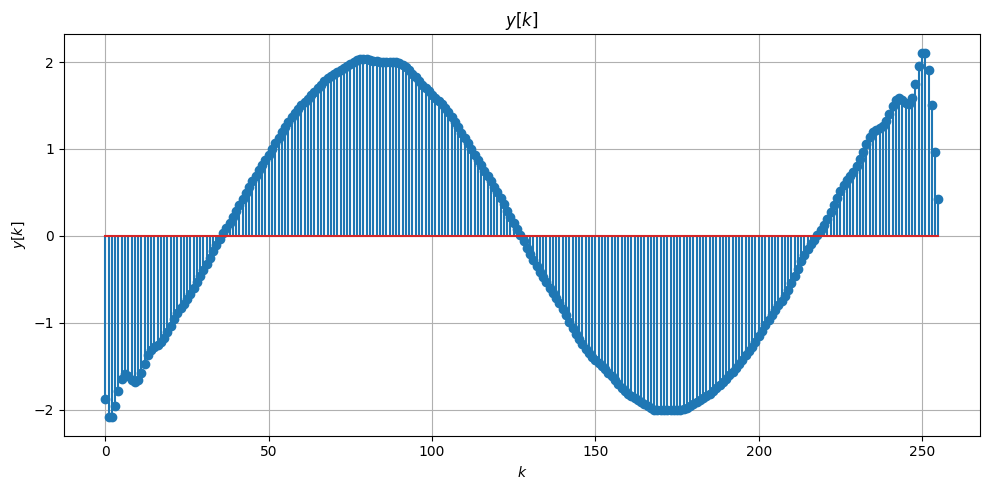

In [223]:
y = y[:(100 * L)]
plt.figure(figsize=[10, 5], dpi=100)
plt.stem(y[:(64 * L)])
plt.title("$y[k]$")
plt.xlabel("$k$")
plt.ylabel("$y[k]$")
plt.tight_layout()
plt.grid()

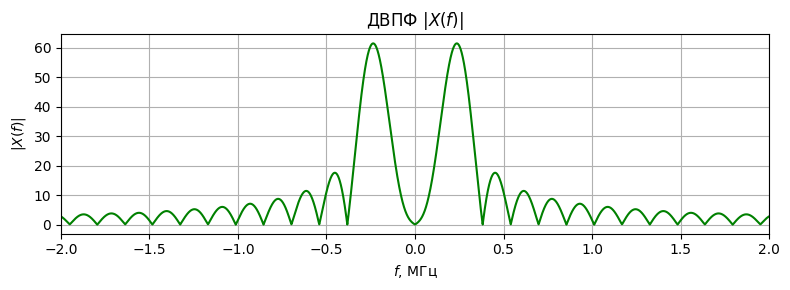

In [224]:
nu, Xn = dtft(x, M=2**18)

plt.figure(figsize=[8, 3], dpi=100)
plt.plot((fs * nu) / 1e6, abs(Xn), "g")
plt.title("ДВПФ $|X(f)|$")
plt.xlabel("$f$, МГц")
plt.ylabel("$|X(f)|$")
plt.xlim(-2*(fs * 0.5) / 1e6 * 0.2, 2*(fs * 0.5) / 1e6 * 0.2)
plt.grid()
plt.tight_layout()
plt.show()

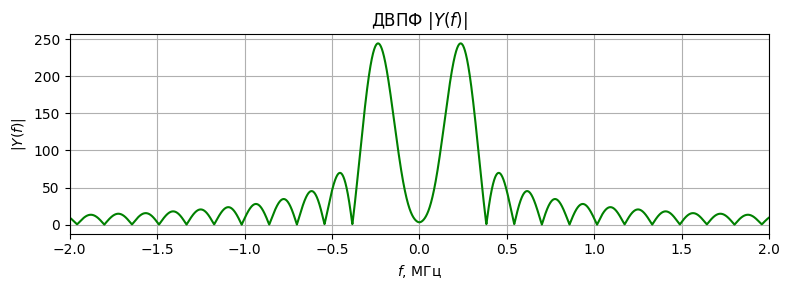

In [225]:
nu, Yn = dtft(y, M=2**18)

plt.figure(figsize=[8, 3], dpi=100)
plt.plot((fs * nu) * L / 1e6, abs(Yn), "g")
plt.title("ДВПФ $|Y(f)|$")
plt.xlabel("$f$, МГц")
plt.ylabel("$|Y(f)|$")
plt.xlim(-2*(fs * 0.5) / 1e6 * 0.2, 2*(fs * 0.5) / 1e6 * 0.2)
plt.grid()
plt.tight_layout()
plt.show()

## Задача 3.2. CIC-фильтры.

Постройте импульсную характеристику и АЧХ (в дБ) CIC-фильтра, состоящего из $Q$ последовательно соединенных каскадов, в каждом из которых длина импульсной характеристики равна $N$.


| Варианты: |   1 |   2 |   3 |   4 |   5 |   6 |   7 |   8 |   9 |   10 |   11 |   12 |   13 |   14 |   15 |   16 |   17 |   18 |   19 |   20 |
|:----|----:|----:|----:|----:|----:|----:|----:|----:|----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|
| $N$ |  16 |  16 |  16 |  16 |  16 |  12 |  12 |  12 |  12 |   12 |   20 |   20 |   20 |   20 |   20 |   32 |   32 |   32 |   32 |   32 |
| $Q$ |   3 |   4 |   5 |   6 |   7 |   3 |   4 |   5 |   6 |    7 |    3 |    4 |    5 |    6 |    7 |    3 |    4 |    5 |    6 |    7 |

Определите максимальный уровень пульсаций фильтра в полосе пропускания (по максимальному уровню бокового лепестка относительно главного). Постройте блок-схему одной из возможных реализаций даннного цифрового фильтра. 





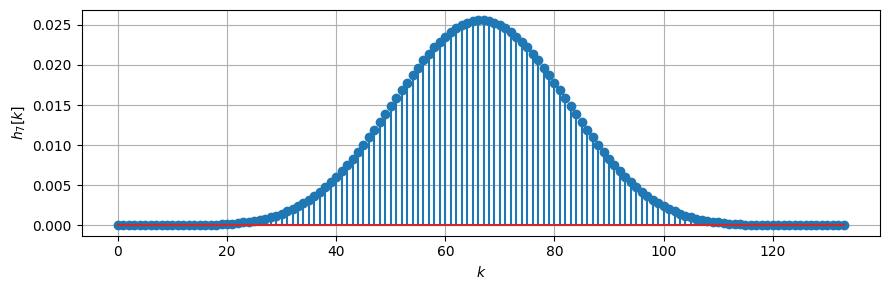

In [226]:
N, Q = 20, 7
ones = np.ones(N)
h = np.ones(N) / N

for _ in range(Q - 1):
    h = np.convolve(h, ones) / N

plt.figure(figsize=[9, 3])
plt.stem(np.arange(h.size), h)
plt.xlabel("$k$")
plt.ylabel(f"$h_{Q}[k]$")
plt.grid()
plt.tight_layout()

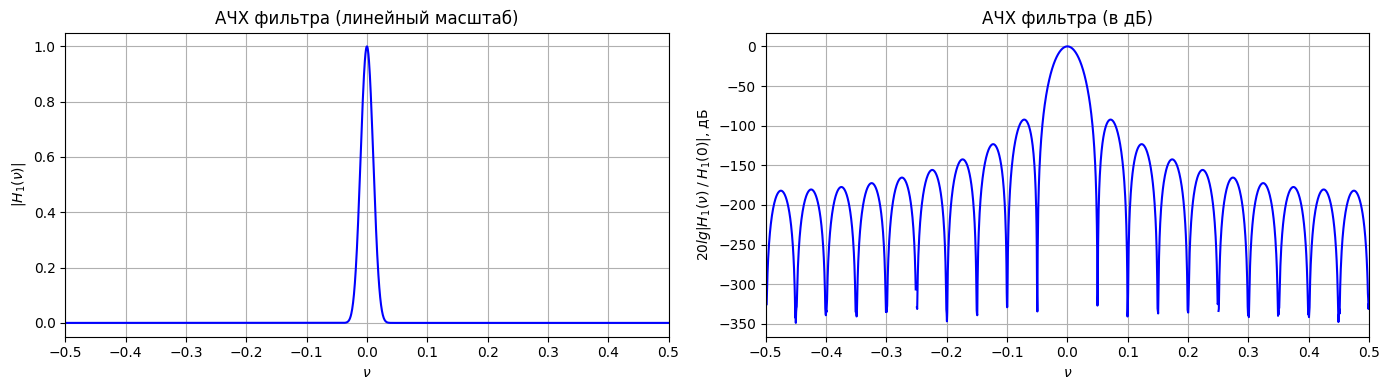

In [227]:
H = np.fft.fftshift(np.fft.fft(h, 2048))
nu = np.arange(H.size) / H.size - 0.5
plt.figure(figsize=[14, 4])
plt.subplot(1, 2, 1)
plt.plot(nu, abs(H), "b")
plt.xlim([-0.5, 0.5])
plt.xticks(np.arange(-0.5, 0.6, 0.1))
plt.xlabel("$\\nu$")
plt.ylabel("|$H_1(\\nu)|$")
plt.title("АЧХ фильтра (линейный масштаб)")
plt.grid()

plt.subplot(1, 2, 2)
with np.errstate(divide='ignore'):
    plt.plot(nu, 20 * np.log10(abs(H) / max((abs(H)))), "b")
plt.xlim([-0.5, 0.5])
plt.xticks(np.arange(-0.5, 0.6, 0.1))
plt.xlabel("$\\nu$")
plt.ylabel("$20 lg|H_1(\\nu)\\;/\\;H_1(0)|$, дБ")
plt.title("АЧХ фильтра (в дБ)")
plt.grid()
plt.tight_layout()

Уровень пульсаций примерно 93дБ.